<a href="https://colab.research.google.com/github/Ololade117/stat4datascience/blob/main/SQ4DS_Lecture_7_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistics and Quantitative Methods for Data Science
[© Silvadew Institute](https://institute.silvadew.com/course-details/?c=43177d50)

# Lecture 14.  Unsupervised Learning: Clustering & Dimensionality Reduction
### Statistics & Quantitative Methods for Data Science

Every model so far has been **supervised** — we had a labeled target (`survived`, `fare`) to predict. **Unsupervised learning** has no target at all: the goal is to find structure — groups, or simpler representations — in the features themselves. Both techniques here rest directly on statistics you already know: distance and variance.

**This notebook:**
1. The unsupervised learning problem
2. K-Means clustering
3. Choosing k: the elbow method & silhouette score
4. Dimensionality reduction: PCA, from covariance to components
5. Visualizing high-dimensional data in 2D with PCA
6. Combining PCA + clustering
7. Exercises


## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

np.random.seed(42)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (7, 4)

TITANIC_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
titanic = pd.read_csv(TITANIC_URL)
df = titanic.dropna(subset=['age','fare','pclass','sibsp','parch']).copy()

---
# 1. The unsupervised learning problem

No `y` this time — just a feature matrix `X`. Two classic questions:
- **Clustering**: which rows are naturally similar to each other? (grouping)
- **Dimensionality reduction**: can we summarize many correlated features with far fewer numbers, losing as little information as possible? (compression)

Both rest on ideas we already have: clustering uses **distance** (like KNN, Week 5); dimensionality reduction uses **variance and covariance** (Week 1 and Week 4's correlation).

---
# 2. K-Means clustering

K-Means partitions data into $k$ groups by iterating two steps until convergence:
1. Assign each point to its nearest **centroid** (cluster center)
2. Recompute each centroid as the mean of the points assigned to it

It directly minimizes **within-cluster variance** — literally the sum of squared distances from each point to its cluster's mean, the same sum-of-squares idea behind Week 1's variance formula.

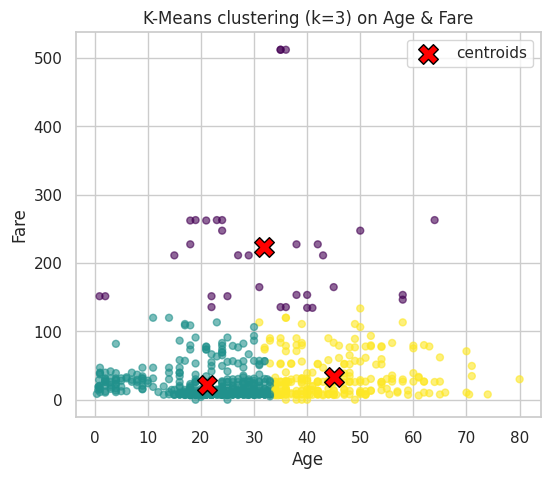

In [ ]:
features = ['age', 'fare']
X = df[features].to_numpy()
X_scaled = StandardScaler().fit_transform(X)   # K-Means uses distance, so scaling matters (like KNN)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_scaled)
df['cluster'] = kmeans.labels_

fig, ax = plt.subplots(figsize=(6,5))
scatter = ax.scatter(df['age'], df['fare'], c=df['cluster'], cmap='viridis', alpha=0.6, s=25)
centroids_original = StandardScaler().fit(X).inverse_transform(kmeans.cluster_centers_)
ax.scatter(centroids_original[:,0], centroids_original[:,1], marker='X', s=200, color='red', edgecolor='black', label='centroids')
ax.set_xlabel('Age'); ax.set_ylabel('Fare'); ax.legend()
ax.set_title('K-Means clustering (k=3) on Age & Fare')
plt.show()

In [ ]:
# What do the clusters actually represent? Profile them against variables NOT used to cluster
print(df.groupby('cluster')[['age','fare']].mean().round(1))
print()
print("Survival rate by cluster (a variable we did NOT cluster on):")
print(df.groupby('cluster')['survived'].mean().round(3))
print(pd.crosstab(df['cluster'], df['pclass'], normalize='index').round(2))

          age   fare
cluster             
0        32.0  222.9
1        21.1   21.6
2        45.1   32.8

Survival rate by cluster (a variable we did NOT cluster on):
cluster
0    0.758
1    0.397
2    0.375
Name: survived, dtype: float64
pclass      1     2     3
cluster                  
0        1.00  0.00  0.00
1        0.12  0.25  0.64
2        0.42  0.27  0.31


---
# 3. Choosing k: the elbow method & silhouette score

K-Means requires you to *choose* $k$ upfront. Two standard statistical diagnostics help:

- **Elbow method**: plot within-cluster sum of squares (**inertia**) vs. $k$. Look for the point where adding more clusters stops helping much — the "elbow."
- **Silhouette score**: for each point, compares its average distance to points in its own cluster vs. the nearest other cluster. Ranges -1 to 1; higher is better-separated.

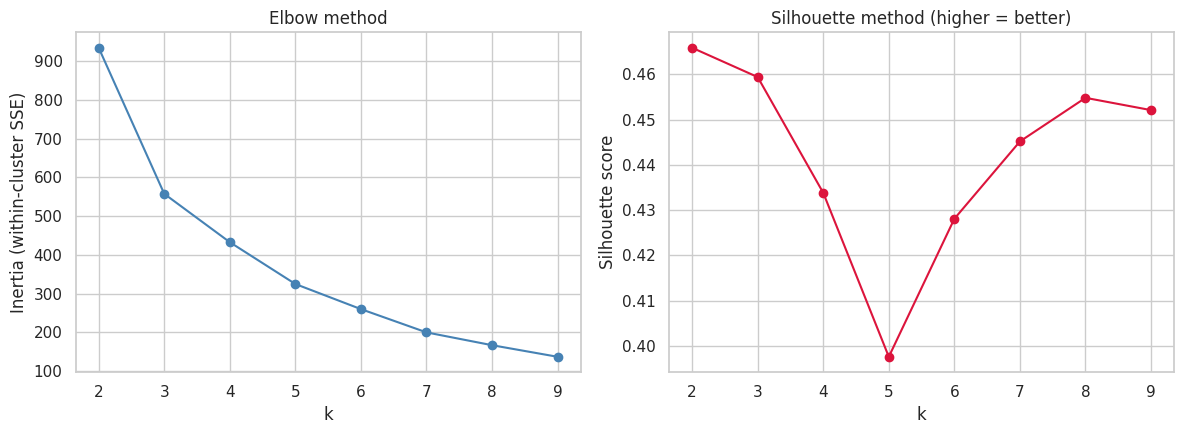

Best k by silhouette score: 2


In [ ]:
inertias, silhouettes = [], []
k_range = range(2, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
axes[0].plot(k_range, inertias, marker='o', color='steelblue')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].set_title('Elbow method')

axes[1].plot(k_range, silhouettes, marker='o', color='crimson')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette method (higher = better)')
plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(silhouettes)]
print(f"Best k by silhouette score: {best_k}")

---
# 4. Dimensionality reduction: PCA, from covariance to components

**Principal Component Analysis (PCA)** finds new axes (**principal components**) that are linear combinations of the original features, chosen so the first axis captures the **maximum possible variance**, the second captures the most *remaining* variance while staying perpendicular to the first, and so on.

Under the hood, PCA is an eigendecomposition of the **covariance matrix** — the same covariance from Week 4's correlation formula, just for many features at once.

In [ ]:
pca_features = ['pclass', 'age', 'sibsp', 'parch', 'fare']
X_multi = StandardScaler().fit_transform(df[pca_features])

pca = PCA()
X_pca = pca.fit_transform(X_multi)

print("Explained variance ratio per component:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {ratio:.3f}  (cumulative: {pca.explained_variance_ratio_[:i+1].sum():.3f})")

Explained variance ratio per component:
  PC1: 0.348  (cumulative: 0.348)
  PC2: 0.323  (cumulative: 0.671)
  PC3: 0.138  (cumulative: 0.809)
  PC4: 0.118  (cumulative: 0.927)
  PC5: 0.073  (cumulative: 1.000)


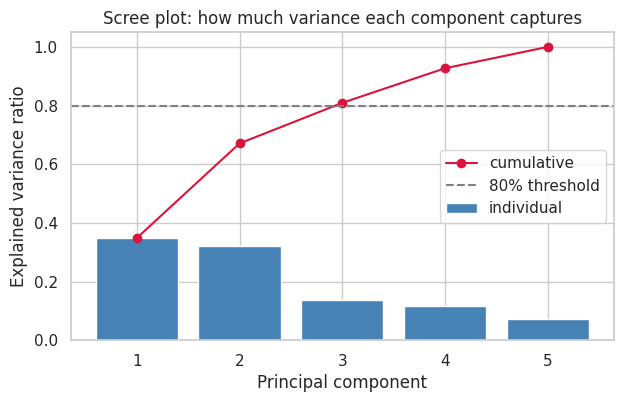

In [ ]:
plt.bar(range(1, len(pca_features)+1), pca.explained_variance_ratio_, color='steelblue', label='individual')
plt.plot(range(1, len(pca_features)+1), np.cumsum(pca.explained_variance_ratio_), color='crimson', marker='o', label='cumulative')
plt.axhline(0.8, color='gray', linestyle='--', label='80% threshold')
plt.xlabel('Principal component'); plt.ylabel('Explained variance ratio'); plt.legend()
plt.title('Scree plot: how much variance each component captures')
plt.show()

In [ ]:
# What do the components MEAN? Look at the loadings -- how much each original feature contributes
loadings = pd.DataFrame(pca.components_[:2].T, index=pca_features, columns=['PC1', 'PC2'])
print(loadings.round(3))
print("\n-> Features with large |loading| on a component are what that component mostly represents.")

          PC1    PC2
pclass  0.621 -0.274
age    -0.546 -0.197
sibsp   0.312  0.540
parch   0.206  0.563
fare   -0.420  0.527

-> Features with large |loading| on a component are what that component mostly represents.


---
# 5. Visualizing high-dimensional data in 2D with PCA

5 features can't be plotted directly. Projecting onto just the first 2 principal components gives a 2D picture that preserves as much of the original variance as any 2D projection can.

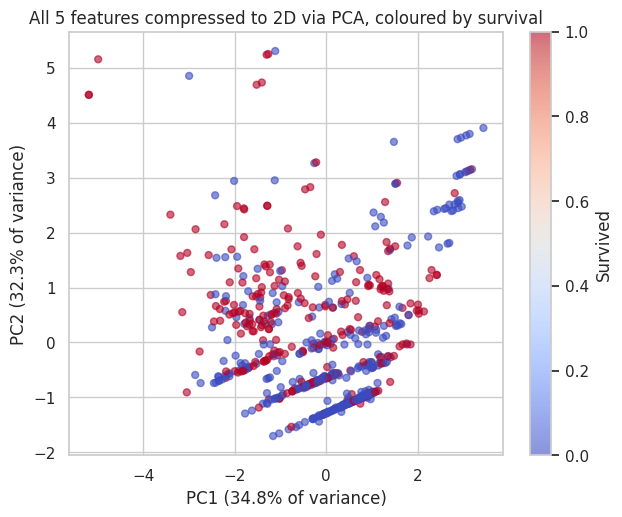

In [ ]:
fig, ax = plt.subplots(figsize=(7,5.5))
scatter = ax.scatter(X_pca[:,0], X_pca[:,1], c=df['survived'], cmap='coolwarm', alpha=0.6, s=25)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} of variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} of variance)')
ax.set_title('All 5 features compressed to 2D via PCA, coloured by survival')
plt.colorbar(scatter, label='Survived')
plt.show()

---
# 6. Combining PCA + clustering

A common real-world pattern: reduce dimensionality first, *then* cluster on the compressed representation — this can reduce noise and make distance-based clustering more meaningful when you have many correlated features (the "curse of dimensionality" makes raw high-dimensional distances less informative).

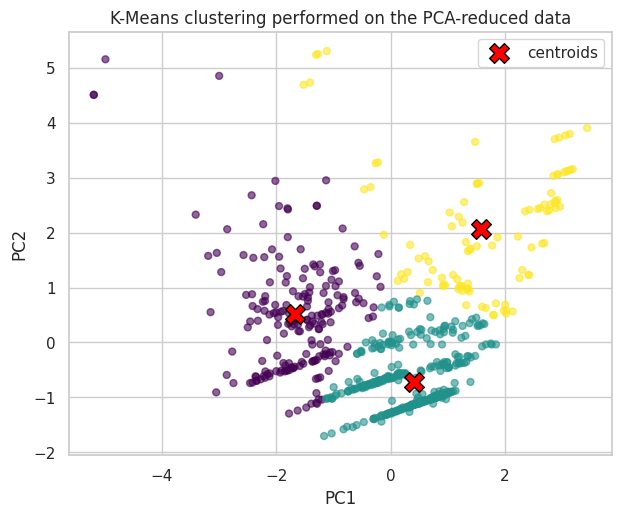

             pclass    age  sibsp  parch   fare  survived
cluster_pca                                              
0              1.09  40.90   0.39   0.34  76.75      0.62
1              2.70  28.36   0.22   0.14  12.59      0.29
2              2.51  13.29   2.01   1.87  46.62      0.49


In [ ]:
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_pca[:, :2])

fig, ax = plt.subplots(figsize=(7,5.5))
ax.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_pca.labels_, cmap='viridis', alpha=0.6, s=25)
ax.scatter(kmeans_pca.cluster_centers_[:,0], kmeans_pca.cluster_centers_[:,1],
           marker='X', s=200, color='red', edgecolor='black', label='centroids')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend()
ax.set_title('K-Means clustering performed on the PCA-reduced data')
plt.show()

df['cluster_pca'] = kmeans_pca.labels_
print(df.groupby('cluster_pca')[pca_features + ['survived']].mean().round(2))

---
# 7. Exercises

1. Re-run K-Means (Section 2) using `['pclass', 'fare']` instead of `['age', 'fare']`. Do the resulting clusters look meaningfully different?
2. Compute the silhouette score for `k=3` on the `['pclass','fare']` clustering from Exercise 1. Is it higher or lower than the best score found in Section 3?
3. Looking at the PCA loadings table (Section 4), write one sentence describing what PC1 seems to represent, based on which features load most heavily on it.
4. How many principal components are needed to capture at least 90% of the variance in `pca_features`? (Read it off the cumulative line in the scree plot, or compute it directly.)
5. **Challenge**: Cluster the *raw* 5 `pca_features` (not PCA-reduced) with `k=3`, and compare the resulting cluster assignments to the PCA-then-cluster result from Section 6 (e.g. with `pd.crosstab`). Do the two approaches largely agree on groupings, or diverge?
